# 03 - Sampler diagnostics: Gaussian and Student-t Gibbs

Runs both production samplers end-to-end on the SPY 1994-2019 training
window at full chain budget (`4 chains x 6000 draws + 2000 burn`) and
exposes the diagnostics a reader needs to trust the posterior:

* trace plots per chain, per representative parameter
* posterior densities for the same representative subset
* `R-hat` and `ESS` summaries across all scalar parameters
* RW-MH acceptance trajectory for the `nu` block of the t-sampler
* Gaussian-vs-Student-t side-by-side overlay on shared parameters

Production-budget chains take real time, so traces are cached to
`data/processed/traces/` keyed by a `sha256` of the regression inputs
plus sampler kwargs. Any drift in `features.build_features` or
`targets.mc_returns` invalidates the cache automatically -- not just
sampler-config drift -- so the diagnostics shown here are guaranteed
to match the data the sampler actually saw.

This notebook is **post-Bayesian** in the sense that it *runs* the
posterior sampler, but it stops at the trace. Thompson decision rule,
policy iteration, and rollout enter in nb 04. All plotting is
delegated to `project.plots`.

In [1]:
import sys
from pathlib import Path

NB_ROOT = Path.cwd().resolve()
SRC = NB_ROOT.parent / "src"
if str(SRC) not in sys.path:
    sys.path.insert(0, str(SRC))

import hashlib
import pickle
import time

import arviz as az
import numpy as np
import pandas as pd
from IPython.display import display

from project import data, env, features, plots, priors, sampler, sampler_t, targets
from project.utils import set_seed, ensure_dirs

ensure_dirs()
rng = set_seed()
SEED = 12345

## Data load and regression-input construction

Builds the `(X, y, a)` triple the Bayesian sampler will fit:

* `X` -- the four-feature design matrix on SPY 1994-2019 training rows
  with non-NaN features.
* `a` -- uniform-random behaviour-policy action *ids* in `[0, n_actions)`,
  the same assumption baked into `baselines._generate_training_data` and
  `tests/test_eval_calibration.py`. We use action *ids* (not labels) so
  the sampler can index `beta[a]` directly.
* `y` -- the truncated MC returns `y_t = sum_{k=0}^H gamma^k R_{t+k}`
  computed via `targets.mc_returns` on the rewards the env emits under
  the behaviour-policy actions.

Rows where the MC window is incomplete (right edge of the sample) or
where features are still in warmup are dropped via the index
intersection. `sigma_y_hat` for prior elicitation is taken as the
empirical std of `y` -- the synthetic recovery test in
`tests/test_sampler_recovery.py` uses the same convention, sidestepping
the dependency on the `sigma_y_pretrain.json` artifact and keeping
nb 03 self-contained.

In [2]:
spy = data.load_spy()
splits = data.split_windows(spy)
prices_train = splits["train"]
feat = features.build_features(spy)
feat_train = feat.reindex(prices_train.index)

# Behaviour policy: uniform-random over the env's three actions.
n_actions = len(env.ACTIONS)
behavior_idx = rng.integers(0, n_actions, size=len(prices_train))
labels = np.asarray(env.ACTIONS, dtype=int)
behavior_labels = labels[behavior_idx]

train_rewards = env.step_reward(prices_train, behavior_labels)
y_series = targets.mc_returns(train_rewards)

# Align (X, y, a) on rows where features are valid AND y is observed.
shared_idx = feat_train.dropna().index.intersection(y_series.index)
X = feat_train.loc[shared_idx].to_numpy(dtype=float)
y_arr = y_series.loc[shared_idx].to_numpy(dtype=float)
behavior_idx_series = pd.Series(behavior_idx, index=prices_train.index)
a_arr = behavior_idx_series.loc[shared_idx].to_numpy().astype(np.int64)

p = X.shape[1]
N = X.shape[0]
sigma_y_hat = float(y_arr.std(ddof=1))

print(f"N (training rows)  = {N:,}")
print(f"p (features)       = {p}")
print(f"n_actions          = {n_actions}")
print(f"y range            = ({y_arr.min():+.4f}, {y_arr.max():+.4f})")
print(f"sigma_y_hat        = {sigma_y_hat:.4f}  (used as the prior scale)")

N (training rows)  = 6,447
p (features)       = 4
n_actions          = 3
y range            = (-0.6698, +0.0082)
sigma_y_hat        = 0.0590  (used as the prior scale)


## Cache contract and chain budget

Production budget is the same one the recovery tests gate on:
`4 chains x 6000 draws + 2000 burn`. The whole point of running this
budget here is so that nb 03's diagnostics ARE the diagnostics -- the
same chains a reader would inspect if they re-ran the project. Trimming
for runtime would make the notebook a toy.

The cache key hashes `(X, y, a)` plus all sampler kwargs. Code changes
to `features.build_features` or `targets.mc_returns` change the inputs,
which changes the hash, which invalidates the cache automatically.

In [3]:
CACHE_DIR = Path("../data/processed/traces")
CACHE_DIR.mkdir(parents=True, exist_ok=True)


def _cache_key(name: str, X: np.ndarray, y: np.ndarray, a: np.ndarray, **kwargs) -> Path:
    h = hashlib.sha256()
    h.update(X.tobytes())
    h.update(y.tobytes())
    h.update(a.tobytes())
    for k, v in sorted(kwargs.items()):
        h.update(f"{k}={v!r}".encode())
    return CACHE_DIR / f"{name}_{h.hexdigest()[:12]}.pkl"


def _load_or_run(name: str, fn, X, y, a, prior_obj, **kwargs):
    key = _cache_key(name, X, y, a, **kwargs)
    if key.exists():
        with open(key, "rb") as f:
            return pickle.load(f), key, True
    trace = fn(X, y, a, prior_obj, **kwargs)
    with open(key, "wb") as f:
        pickle.dump(trace, f)
    return trace, key, False

In [4]:
prior_gauss = priors.make_priors(sigma_y_hat=sigma_y_hat, p=p, n_actions=n_actions)
gauss_kwargs = dict(n_draws=6000, n_burn=2000, n_chains=4, seed=SEED)

t0 = time.time()
trace_gauss, gauss_key, gauss_hit = _load_or_run(
    "gaussian", sampler.gibbs_gaussian, X, y_arr, a_arr, prior_gauss, **gauss_kwargs,
)
gauss_elapsed = time.time() - t0
print(f"Gaussian sampler: {'cache hit' if gauss_hit else 'fresh run'} "
      f"in {gauss_elapsed:.1f}s")
print(f"  cache file = {gauss_key.name}")
print(f"  beta shape = {trace_gauss['beta'].shape}  (chains x draws x actions x p)")

Gaussian sampler: fresh run in 37.3s
  cache file = gaussian_171ca339bccc.pkl
  beta shape = (4, 6000, 3, 4)  (chains x draws x actions x p)


## Gaussian Gibbs: traces and posterior densities (representative subset)

The representative slice is `mu_beta` (4 components), `sigma2` (1), and
the `beta_a` block for action `a=0` (4 components). Showing all 12 betas
plus the rest is plot soup; this slice already exposes the
between-action mean (the headline parameter for downstream Q values)
and one full conjugate Normal-block, which is enough to spot mixing
problems in the per-action conditional update.

Trace plots first (chain-wise mixing reads at a glance), then KDE
posteriors over the same slice (where the mass actually sits).

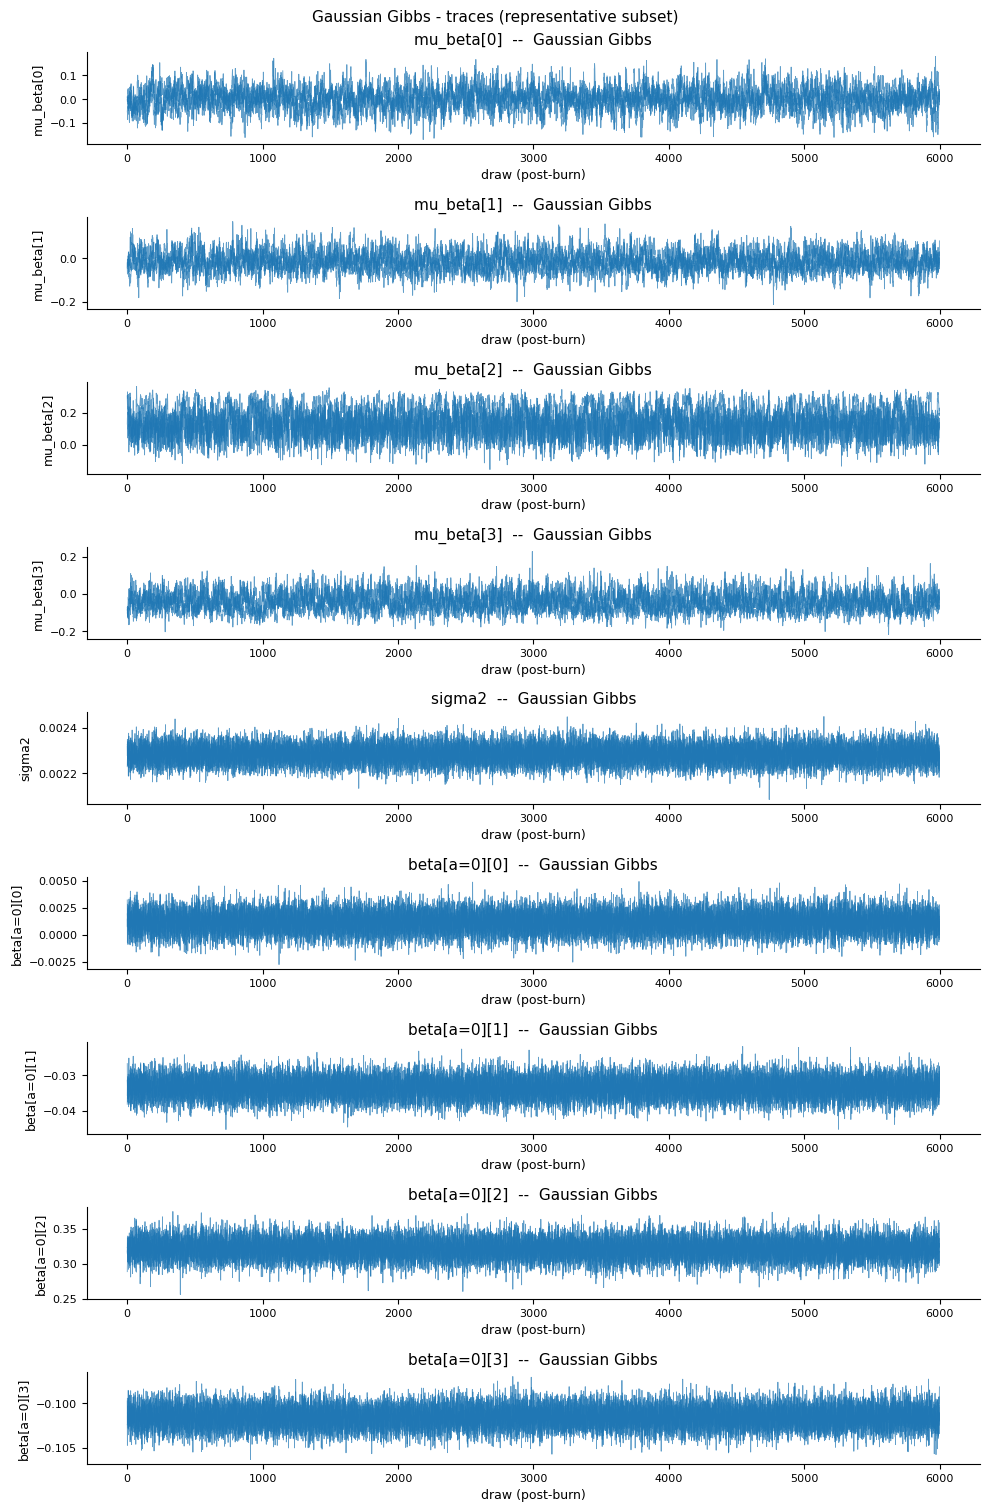

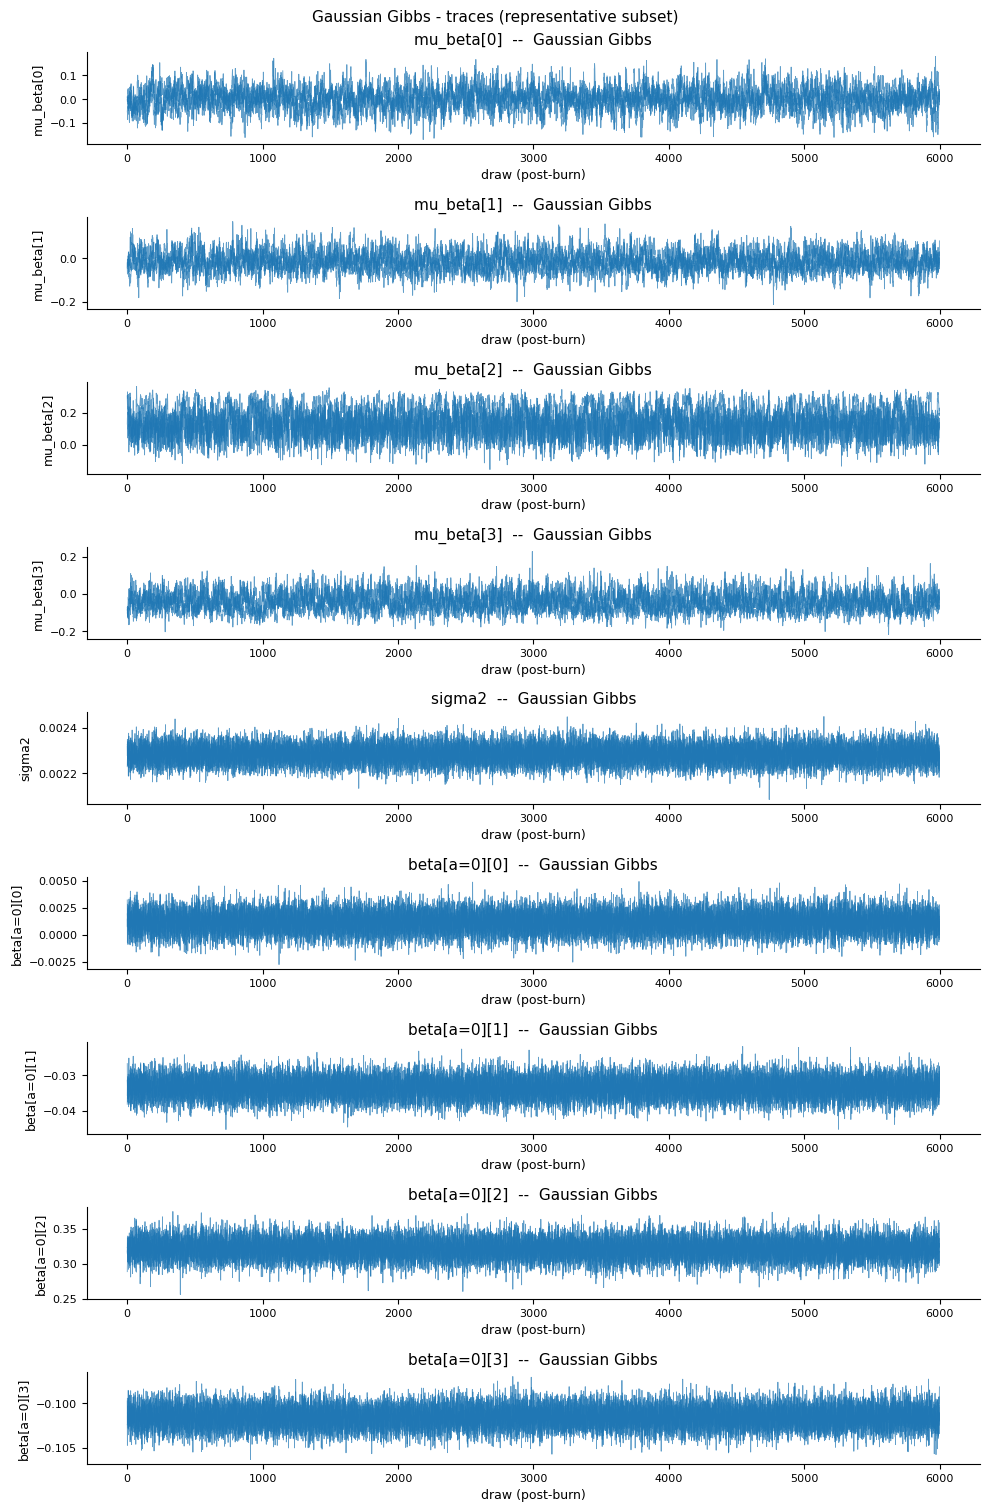

In [5]:
def _representative_subset(trace: dict, p: int, action_for_beta_block: int = 0) -> dict:
    out: dict[str, np.ndarray] = {}
    for j in range(p):
        out[f"mu_beta[{j}]"] = trace["mu_beta"][..., j]
    out["sigma2"] = trace["sigma2"]
    for j in range(p):
        out[f"beta[a={action_for_beta_block}][{j}]"] = trace["beta"][..., action_for_beta_block, j]
    return out


subset_gauss = _representative_subset(trace_gauss, p=p)
fig, _ = plots.plot_trace_grid(subset_gauss, sampler="gaussian")
fig.suptitle("Gaussian Gibbs - traces (representative subset)", fontsize=11, y=1.005)
fig

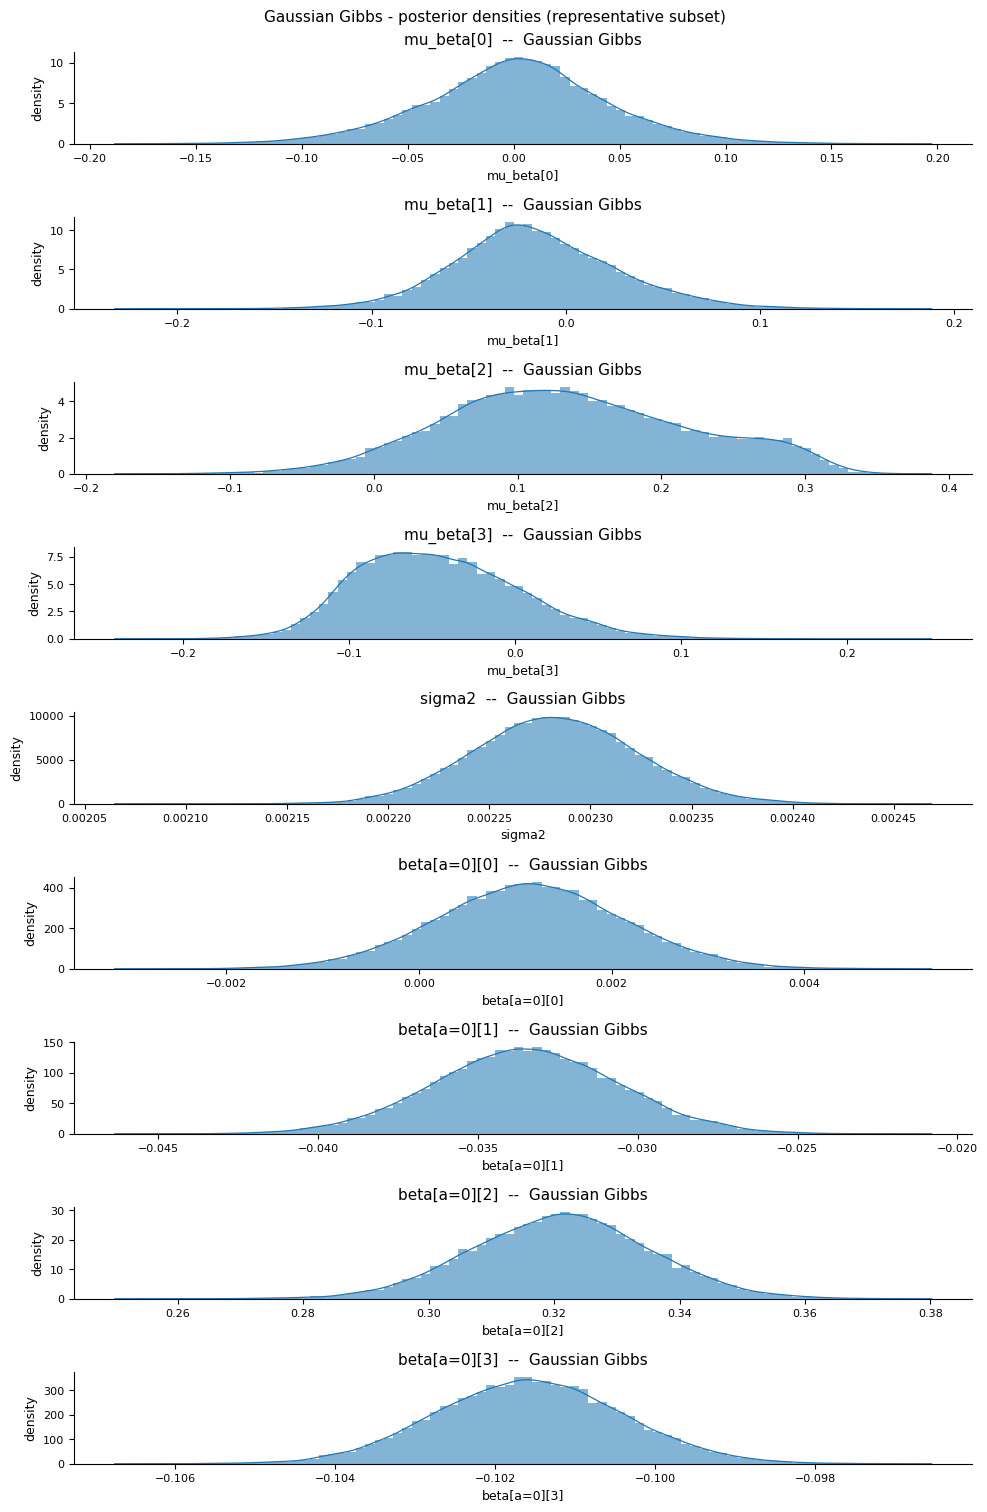

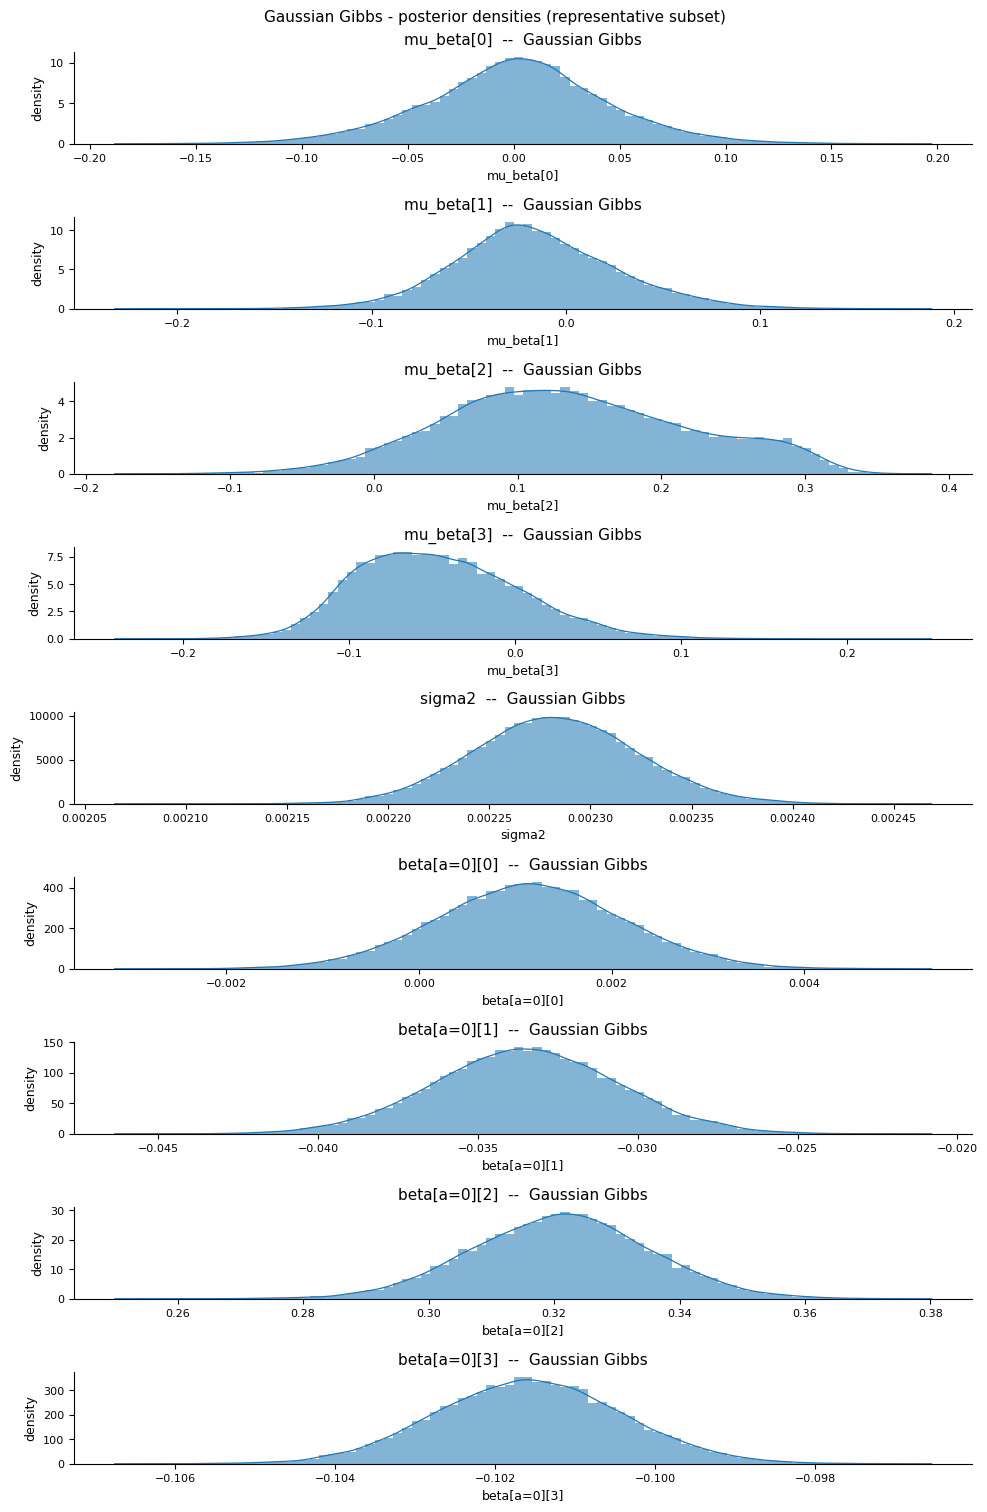

In [6]:
subset_gauss_flat = {k: v.reshape(-1) for k, v in subset_gauss.items()}
fig, _ = plots.plot_posterior_density_grid(subset_gauss_flat, sampler="gaussian")
fig.suptitle("Gaussian Gibbs - posterior densities (representative subset)", fontsize=11, y=1.005)
fig

## Gaussian Gibbs: convergence diagnostics

`R-hat` and `ESS` across all scalar parameters in `(mu_beta, sigma2, beta)`.
Computed via `arviz.rhat` and `arviz.ess` -- the same idiom
`tests/test_sampler_recovery.py:99-107` uses to gate the recovery
contract. The horizontal threshold lines are the project gates: `R-hat <
1.05` everywhere, `ESS >= 400` for `nu` (the t-sampler's mixing-bottleneck
parameter; `mu_beta` and `beta` can legitimately come in lower under the
conjugate blocks without breaking the headline contract).

R-hat: max = 1.0049, all < 1.05? True
ESS:   min = 1731, ESS(sigma2) = 23684


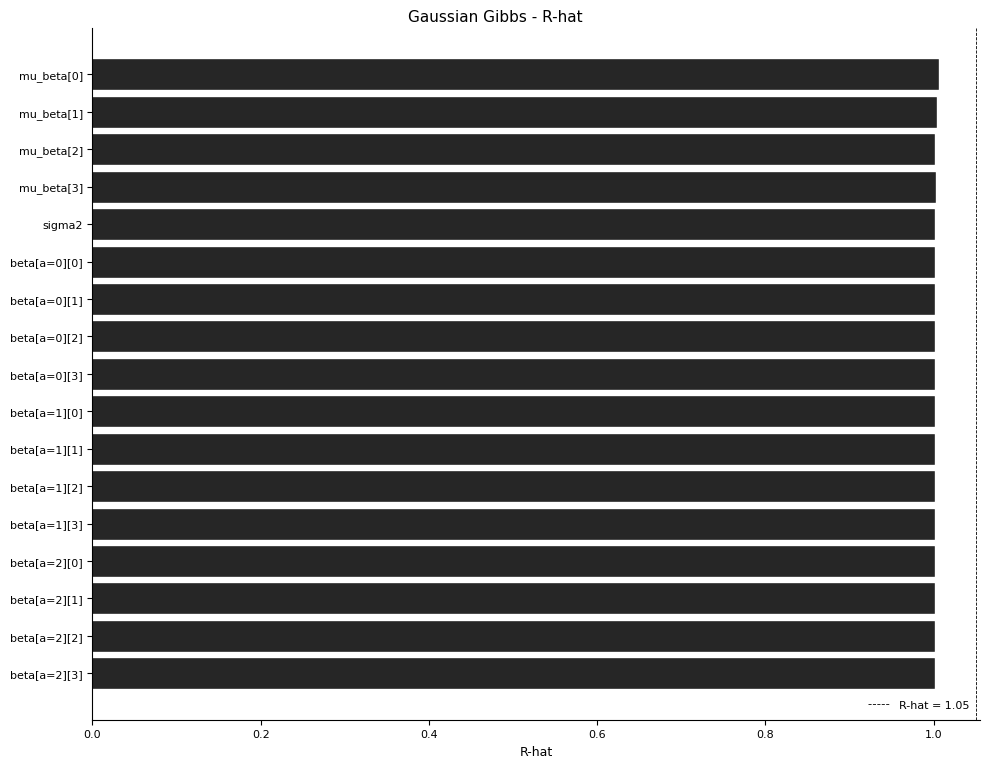

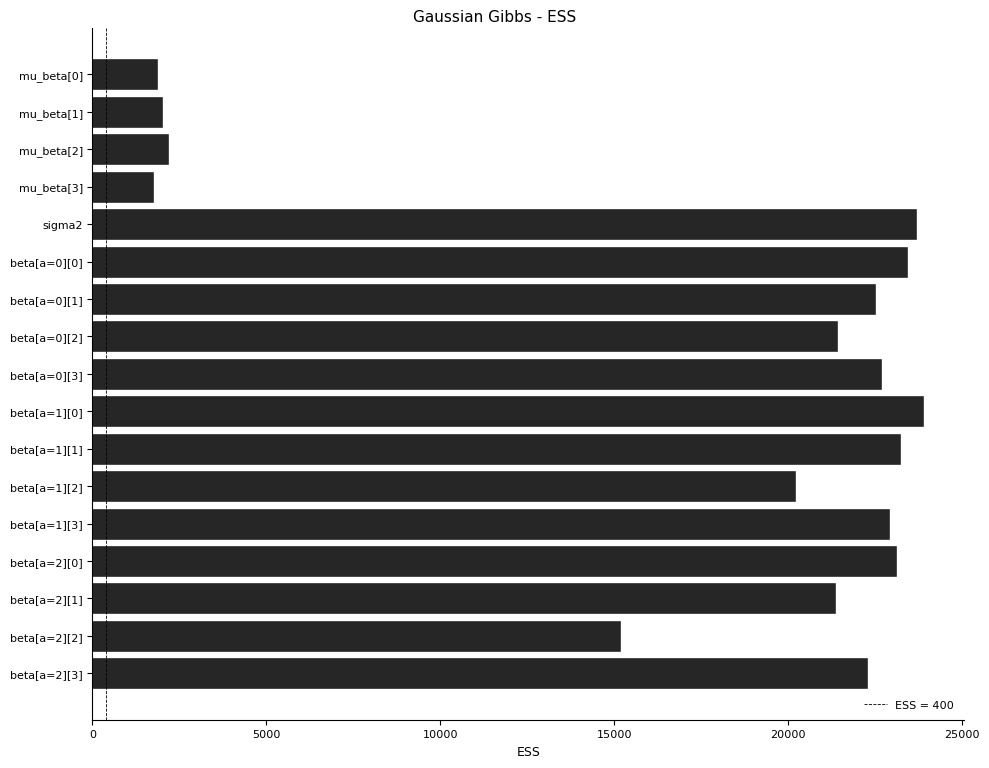

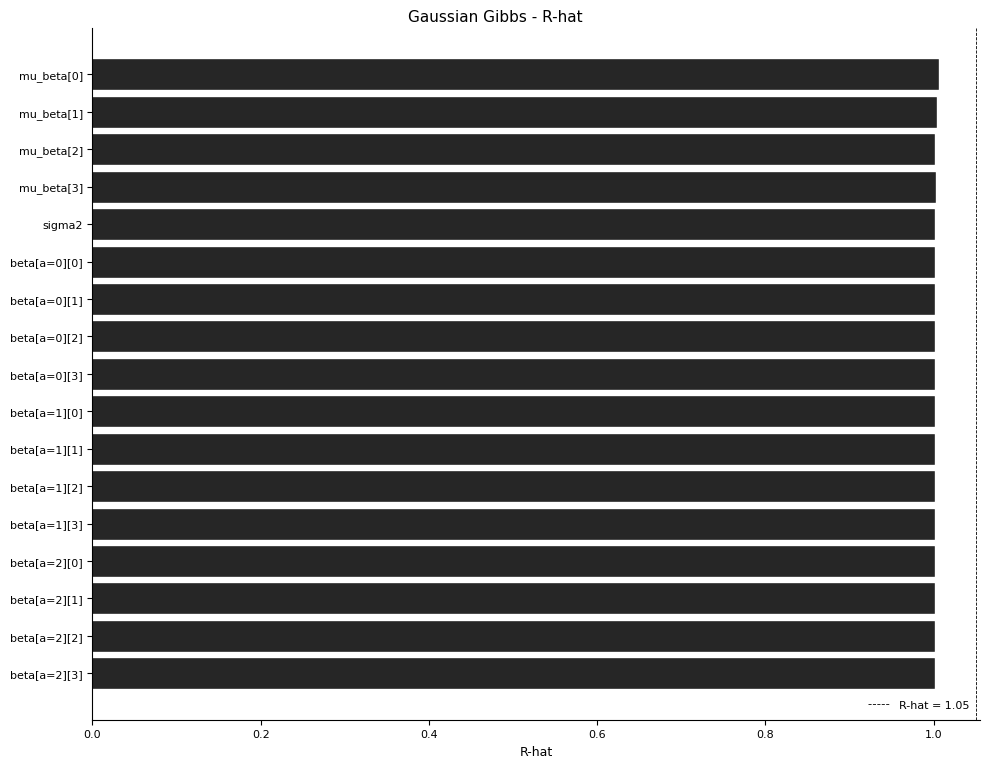

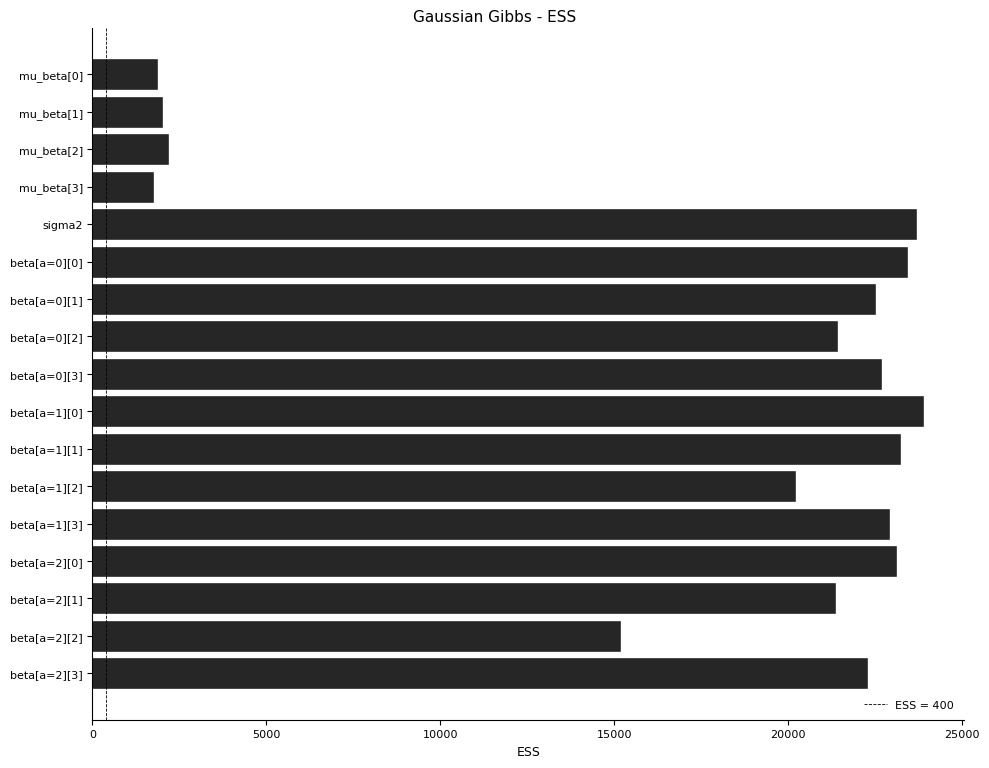

In [7]:
def _rhat_ess_scalars(trace: dict, p: int, n_actions: int) -> tuple[dict, dict]:
    posterior = {
        "mu_beta": trace["mu_beta"],
        "sigma2": trace["sigma2"],
        "beta": trace["beta"],
    }
    if "nu" in trace:
        posterior["nu"] = trace["nu"]
    idata = az.from_dict(posterior=posterior)
    rhat = az.rhat(idata)
    ess = az.ess(idata)
    out_rhat: dict[str, float] = {}
    out_ess: dict[str, float] = {}
    for j in range(p):
        out_rhat[f"mu_beta[{j}]"] = float(rhat["mu_beta"].values[j])
        out_ess[f"mu_beta[{j}]"] = float(ess["mu_beta"].values[j])
    out_rhat["sigma2"] = float(rhat["sigma2"].item())
    out_ess["sigma2"] = float(ess["sigma2"].item())
    if "nu" in trace:
        out_rhat["nu"] = float(rhat["nu"].item())
        out_ess["nu"] = float(ess["nu"].item())
    for k in range(n_actions):
        for j in range(p):
            out_rhat[f"beta[a={k}][{j}]"] = float(rhat["beta"].values[k, j])
            out_ess[f"beta[a={k}][{j}]"] = float(ess["beta"].values[k, j])
    return out_rhat, out_ess


rhat_gauss, ess_gauss = _rhat_ess_scalars(trace_gauss, p=p, n_actions=n_actions)
print(f"R-hat: max = {max(rhat_gauss.values()):.4f}, all < 1.05? {max(rhat_gauss.values()) < 1.05}")
print(f"ESS:   min = {min(ess_gauss.values()):.0f}, ESS(sigma2) = {ess_gauss['sigma2']:.0f}")

fig_rhat, _ = plots.plot_rhat_summary(rhat_gauss)
fig_rhat.suptitle("Gaussian Gibbs - R-hat", fontsize=11, y=1.005)
display(fig_rhat)

fig_ess, _ = plots.plot_ess_summary(ess_gauss)
fig_ess.suptitle("Gaussian Gibbs - ESS", fontsize=11, y=1.005)
display(fig_ess)

## Student-t Gibbs

Same hierarchy as the Gaussian sampler plus per-observation latent
scales `lambda_t ~ Gamma(nu/2, nu/2)`, so the marginal likelihood of
`y_t` is Student-t with `nu` degrees of freedom. The `nu` block uses
random-walk Metropolis on `log nu` with Robbins-Monro adaptation of
the step size during the first half of burn-in -- adaptation freezes
before the post-burn draws begin, so the recorded chain is from a
homogeneous-kernel sampler.

The headline contract here (matching `test_t_recovery_single_replication`):

* `R-hat < 1.05` for every scalar in `(mu_beta, sigma2, nu)`,
* `ESS(nu) >= 400` at production budget,
* RW-MH acceptance for `nu` per chain inside `[0.20, 0.45]`.

This notebook visualises all three contracts and adds the per-draw
acceptance trajectory the recovery test does not show.

In [8]:
prior_t = priors.make_priors_t(sigma_y_hat=sigma_y_hat, p=p, n_actions=n_actions)
t_kwargs = dict(n_draws=6000, n_burn=2000, n_chains=4, seed=SEED)

t0 = time.time()
trace_t, t_key, t_hit = _load_or_run(
    "student_t", sampler_t.gibbs_student_t, X, y_arr, a_arr, prior_t, **t_kwargs,
)
t_elapsed = time.time() - t0
print(f"Student-t sampler: {'cache hit' if t_hit else 'fresh run'} "
      f"in {t_elapsed:.1f}s")
print(f"  cache file              = {t_key.name}")
print(f"  nu_acceptance per chain = {trace_t['nu_acceptance'].round(3).tolist()}")

Student-t sampler: fresh run in 72.9s
  cache file              = student_t_171ca339bccc.pkl
  nu_acceptance per chain = [0.298, 0.283, 0.335, 0.306]


## Student-t Gibbs: traces (representative subset incl. `nu`)

Same representative subset as the Gaussian panel plus the `nu` block.

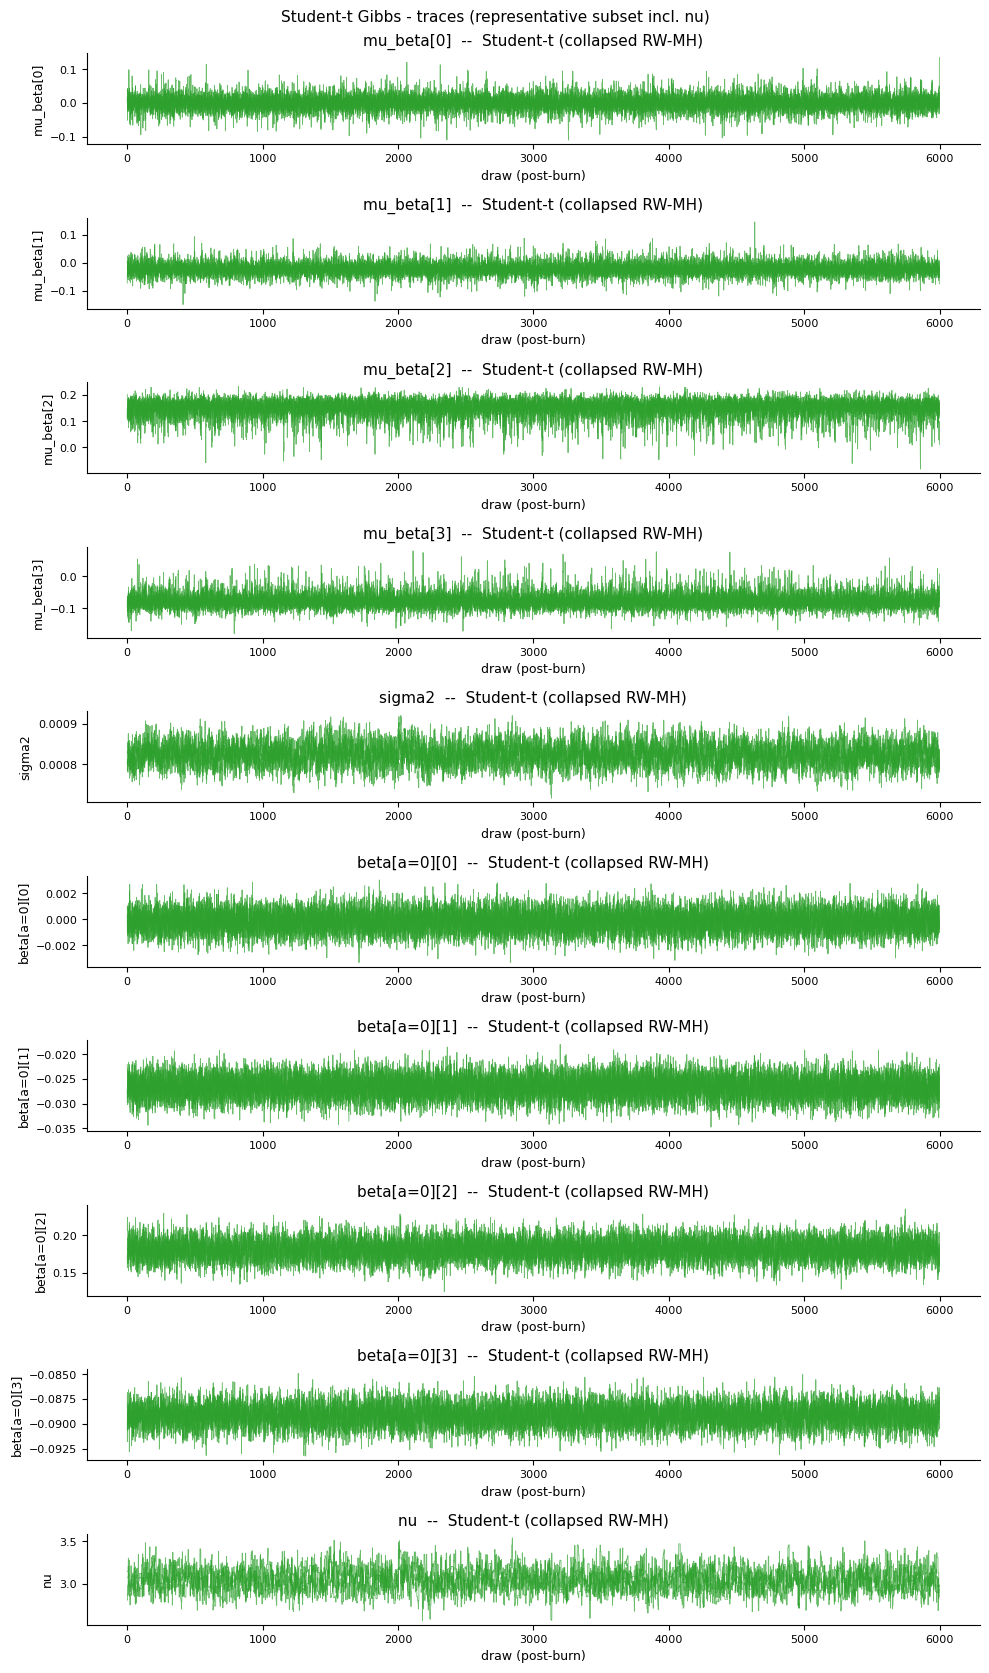

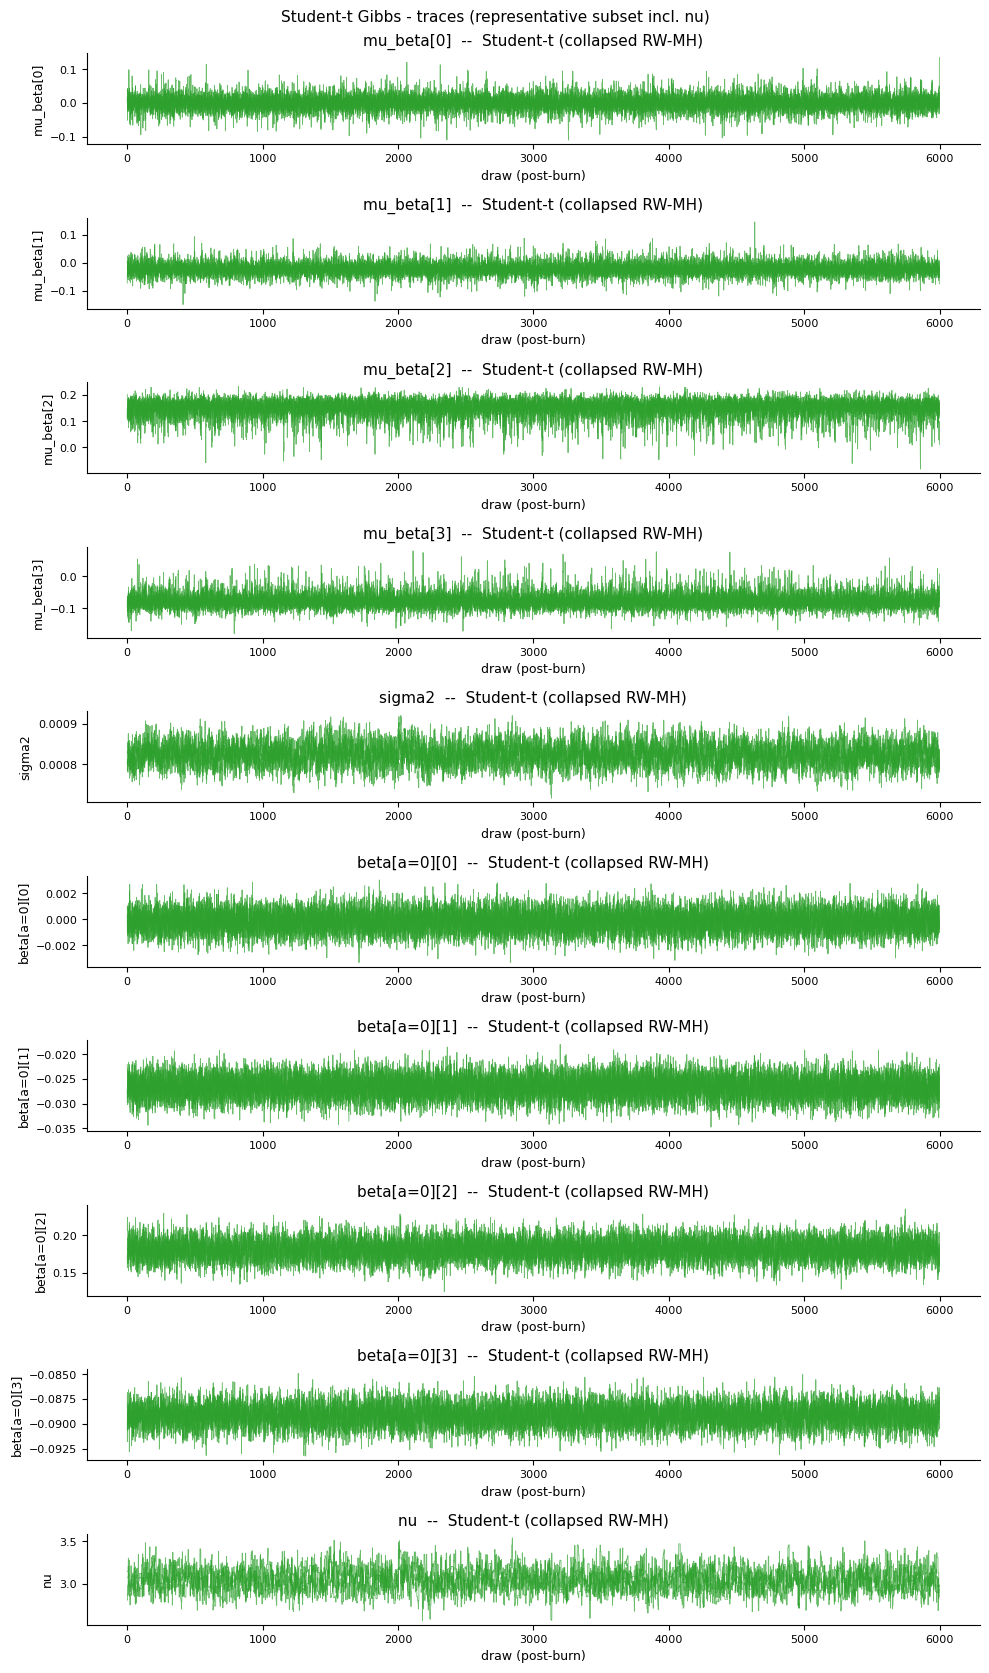

In [9]:
subset_t = _representative_subset(trace_t, p=p)
subset_t["nu"] = trace_t["nu"]
fig, _ = plots.plot_trace_grid(subset_t, sampler="student_t")
fig.suptitle("Student-t Gibbs - traces (representative subset incl. nu)", fontsize=11, y=1.005)
fig

## `nu` posterior, partial collapse, and MH acceptance trajectory

The `nu` block uses the *partially collapsed* MH target
`p(nu | y, beta, sigma^2)` -- with the latent `lambda` weights
integrated out analytically (Liu-Wong-Kong 1994). A reader checking
the math against the standard conjugate-block decomposition will
NOT find a `p(nu | lambda)` step in `propose_log_nu`; the lambdas are
still resampled every sweep for the `beta` and `sigma^2` updates, but
the `nu` block sees only their integrated effect.

Per-draw acceptance is *derived* from the post-burn `nu` chain via
`np.diff(np.log(nu_trace), axis=1) != 0`. The argument is that
`propose_log_nu` perturbs `log_nu` by `step * z` with `z ~ N(0, 1)`,
so the probability of a proposal landing exactly on the previous
`log_nu` in IEEE-754 floating point is zero -- rejection is the only
way two consecutive `log_nu` values match. The next cell sanity-checks
the derived per-chain rate against the sampler's stored aggregate; a
disagreement of more than 1% means the floating-point argument is
breaking on real data and we'd modify the sampler to store a per-draw
acceptance trace directly.

The Exponential(0.1) prior on `nu` has `E[nu] = 10` (Gaussian-tail
scale). If SPY's MC return target distribution prefers a heavier tail,
the posterior will sit visibly below 10.

derived per-draw acceptance: 0.3056
stored aggregate          : 0.3055
|delta|                   : 0.0001  (gate: < 0.01)


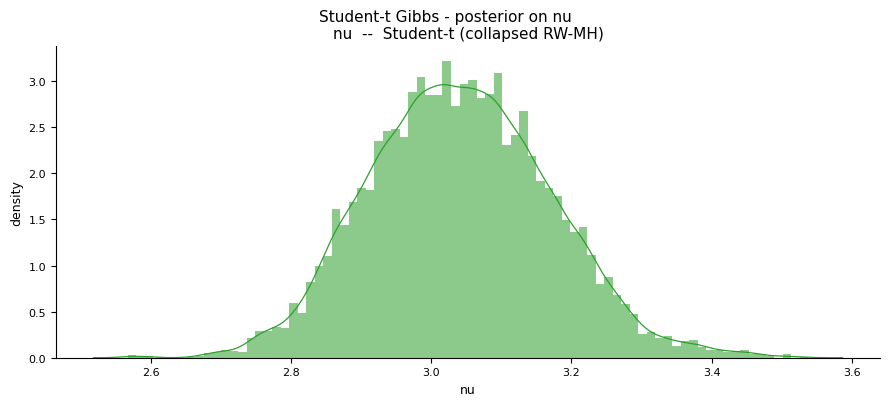

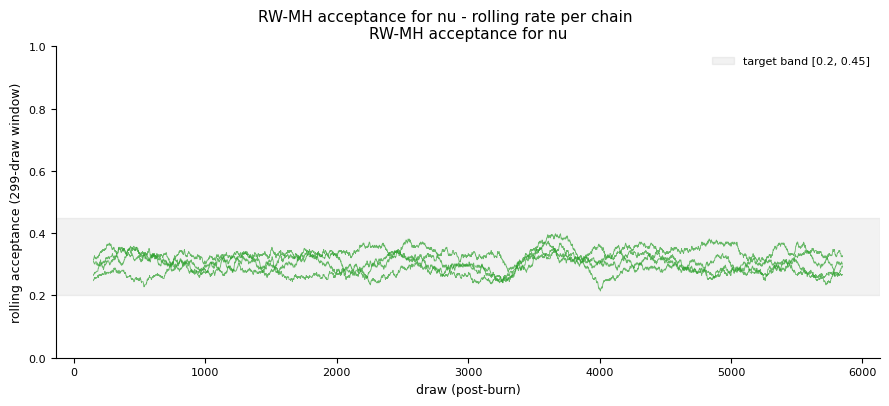

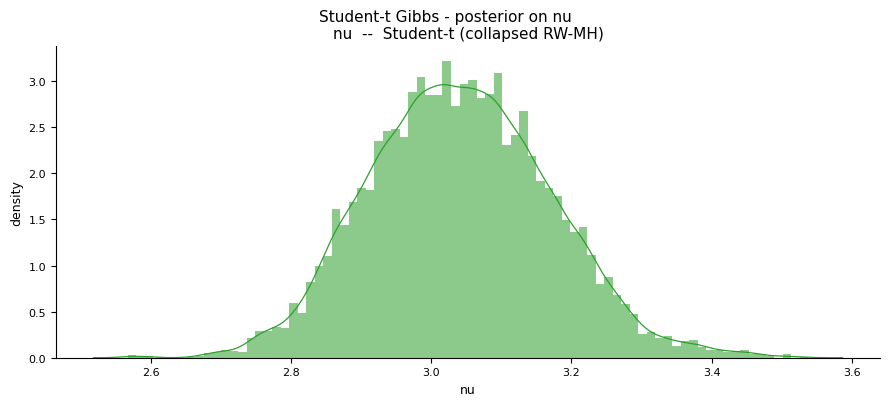

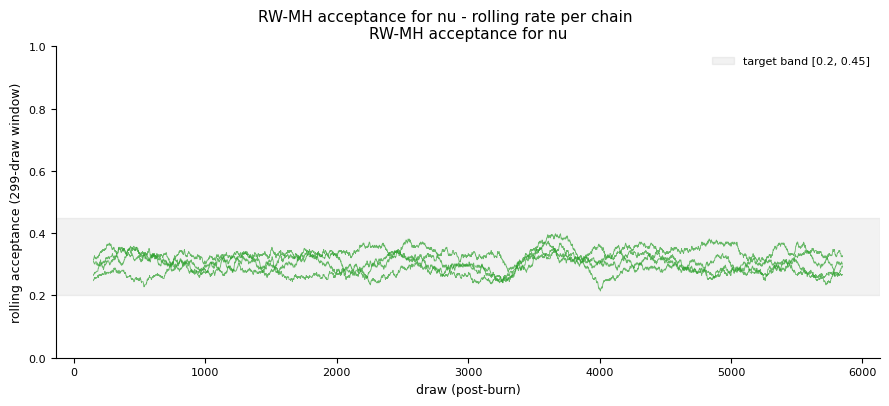

In [10]:
log_nu = np.log(trace_t["nu"])
acc_per_draw = (np.diff(log_nu, axis=1) != 0).astype(np.int8)  # (n_chains, n_draws-1)

derived_aggregate = float(acc_per_draw.mean(axis=1).mean())
stored_aggregate = float(trace_t["nu_acceptance"].mean())
delta = abs(derived_aggregate - stored_aggregate)
print(f"derived per-draw acceptance: {derived_aggregate:.4f}")
print(f"stored aggregate          : {stored_aggregate:.4f}")
print(f"|delta|                   : {delta:.4f}  (gate: < 0.01)")
assert delta < 0.01, (
    "Derived and stored MH acceptance disagree by >1% -- the floating-point "
    "argument for deriving acceptance from the nu trace breaks down on real "
    "data; modify gibbs_student_t to store per-draw nu_accept_trace."
)

fig_nu, _ = plots.plot_posterior_density(
    trace_t["nu"].reshape(-1), param_name="nu", sampler="student_t",
)
fig_nu.suptitle("Student-t Gibbs - posterior on nu", fontsize=11, y=1.005)
display(fig_nu)

fig_acc, _ = plots.plot_mh_acceptance(acc_per_draw)
fig_acc.suptitle("RW-MH acceptance for nu - rolling rate per chain", fontsize=11, y=1.005)
display(fig_acc)

## Student-t Gibbs: convergence diagnostics

Same shape as the Gaussian summary plus the `nu` row. The ESS bar for
`nu` is the production-budget gate.

R-hat: max = 1.0039, all < 1.05? True
ESS(nu) = 1724  (gate: >= 400)


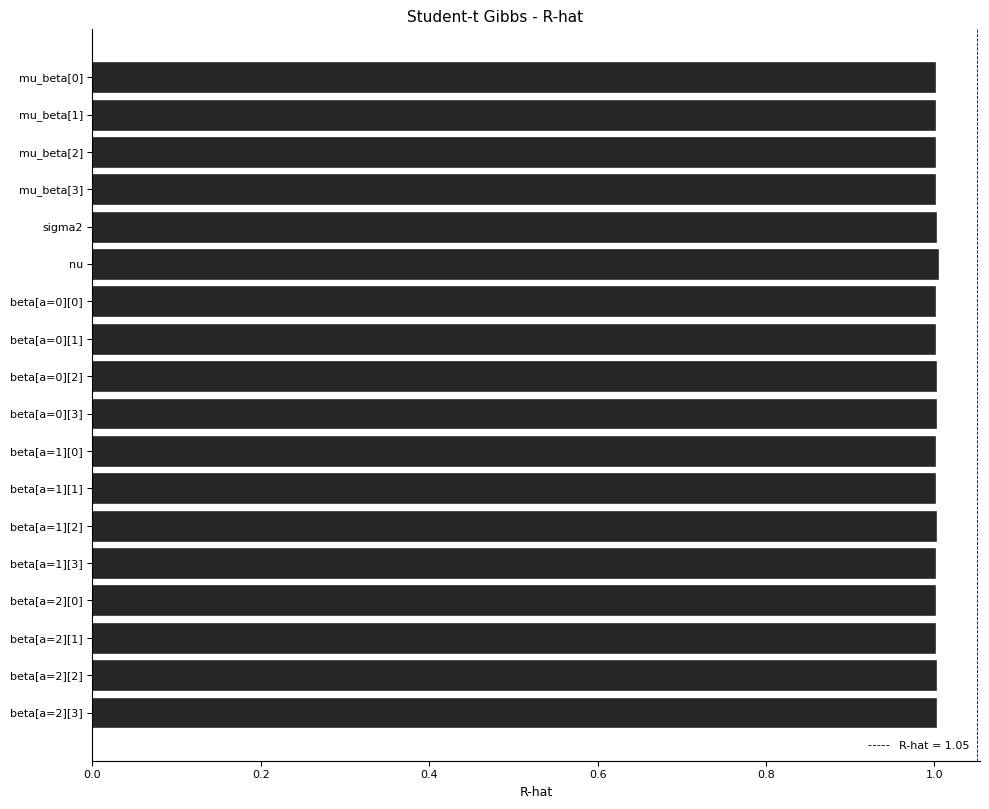

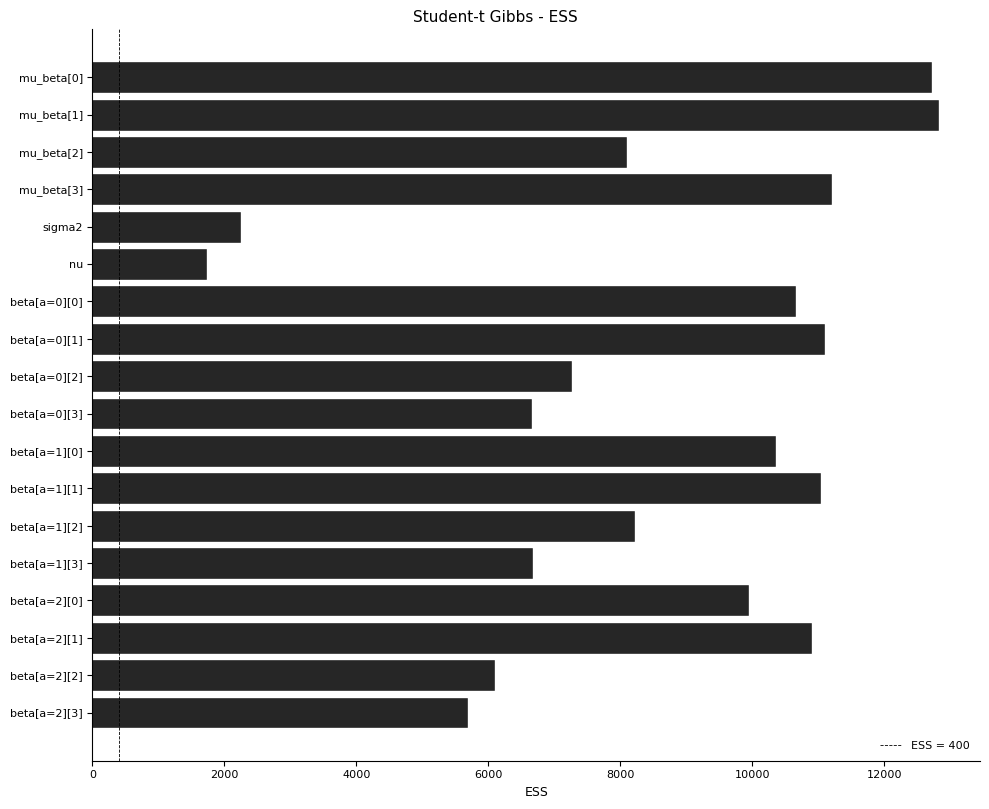

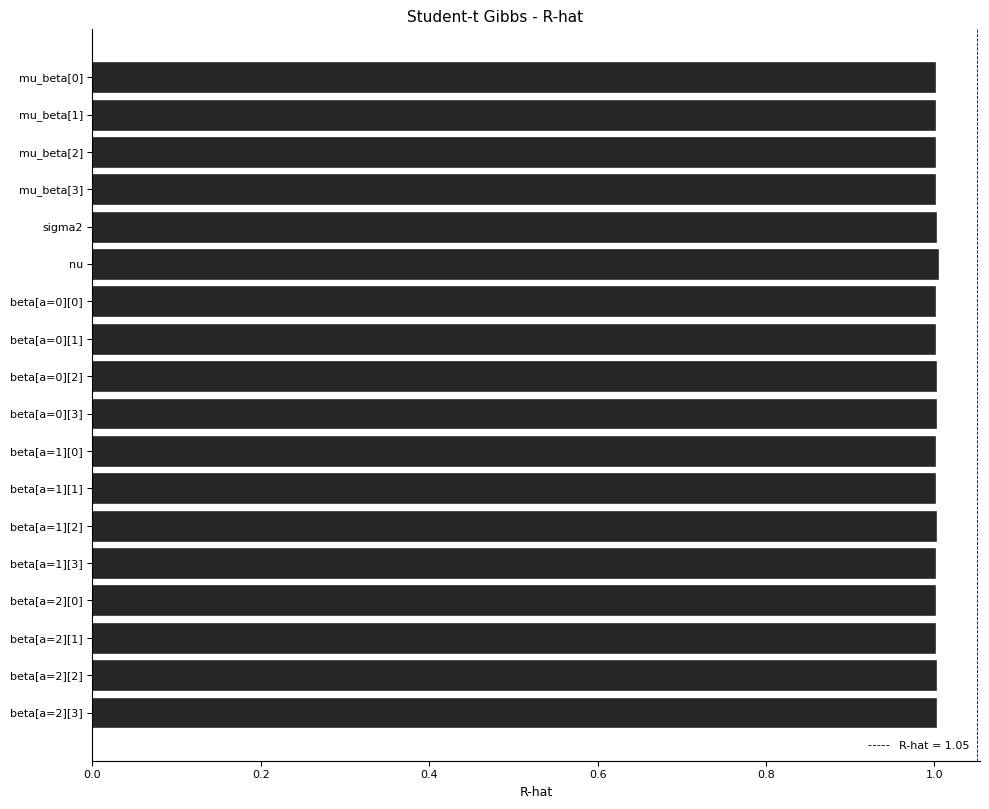

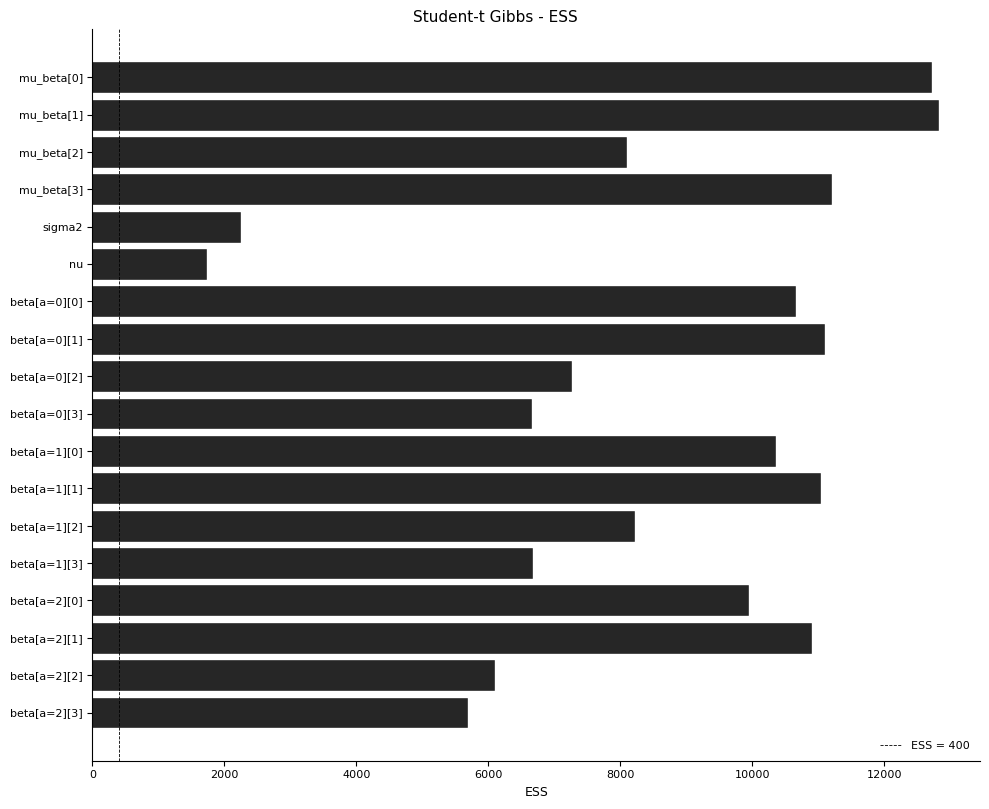

In [11]:
rhat_t, ess_t = _rhat_ess_scalars(trace_t, p=p, n_actions=n_actions)
print(f"R-hat: max = {max(rhat_t.values()):.4f}, all < 1.05? {max(rhat_t.values()) < 1.05}")
print(f"ESS(nu) = {ess_t['nu']:.0f}  (gate: >= 400)")

fig_rhat_t, _ = plots.plot_rhat_summary(rhat_t)
fig_rhat_t.suptitle("Student-t Gibbs - R-hat", fontsize=11, y=1.005)
display(fig_rhat_t)

fig_ess_t, _ = plots.plot_ess_summary(ess_t)
fig_ess_t.suptitle("Student-t Gibbs - ESS", fontsize=11, y=1.005)
display(fig_ess_t)

## Gaussian vs Student-t: posterior overlay on shared parameters

Same data, two samplers, what does the heavy-tail model buy us?

For each `mu_beta[j]` component and for `sigma2`, we overlay the
Gaussian-sampler posterior (blue, `C0`) and the Student-t-sampler
posterior (green, `C2`) on a single axes. If the heavy-tail
specification is doing real work, expect the t-posterior on `sigma2`
to be visibly tighter (residual variance is no longer paying for the
tail mass that `nu` now absorbs) and the `mu_beta` posteriors to
shift slightly relative to the Gaussian fit.

(Five separate figures rather than a 5-panel grid: the per-figure
overlay helper is the only public diagnostic for this comparison; a
multi-panel wrapper is mission creep this round and lands later if
nb 09's sensitivity sweep needs it.)

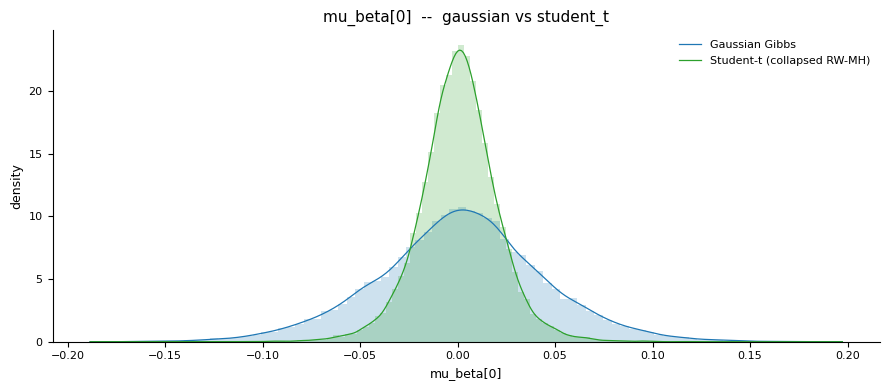

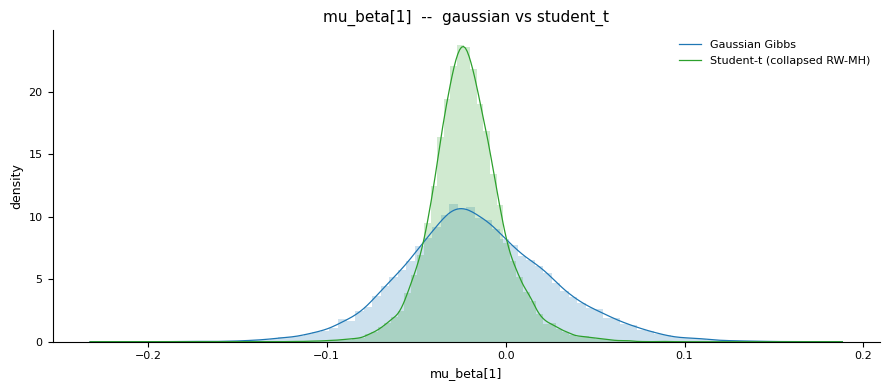

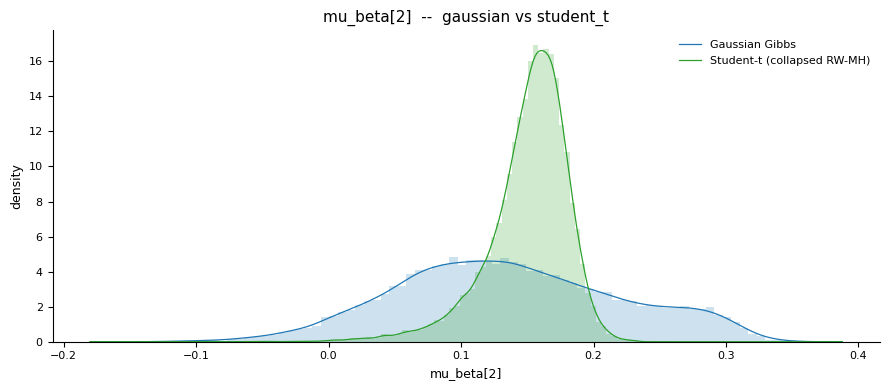

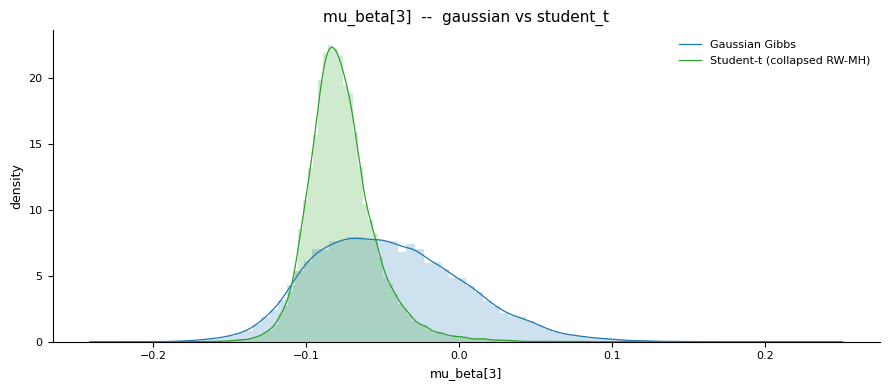

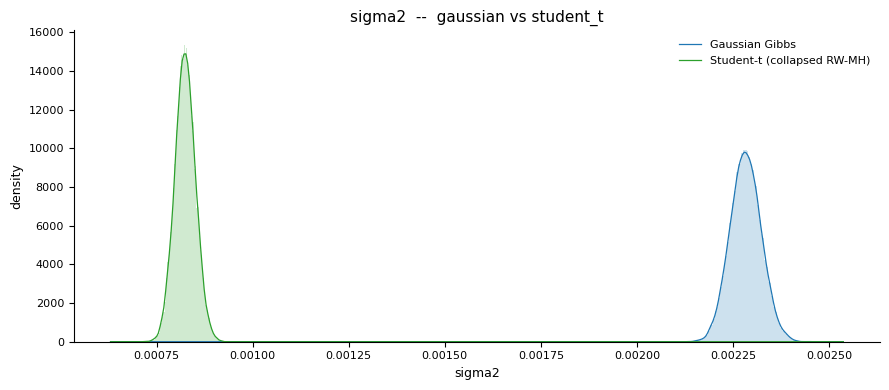

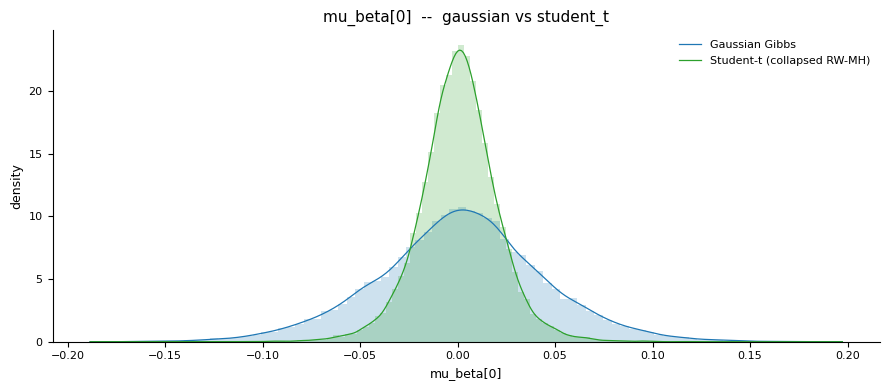

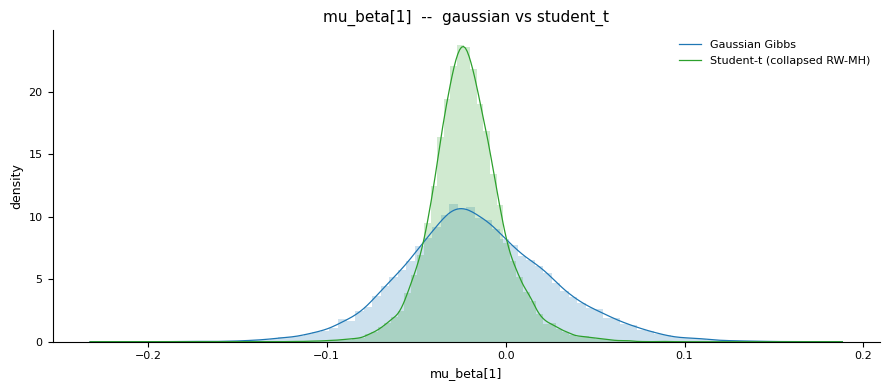

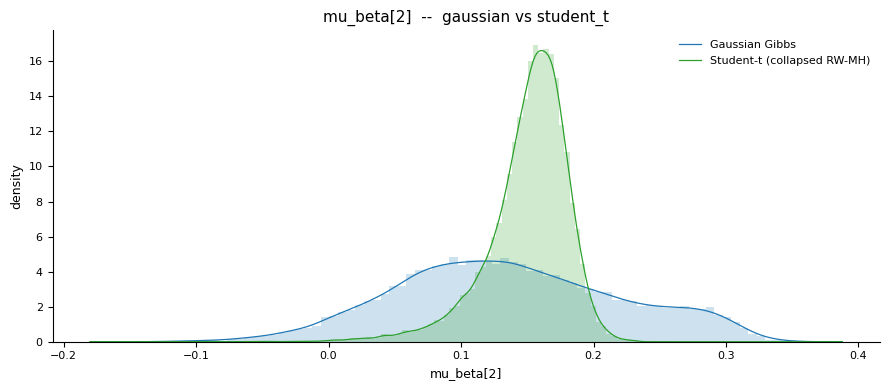

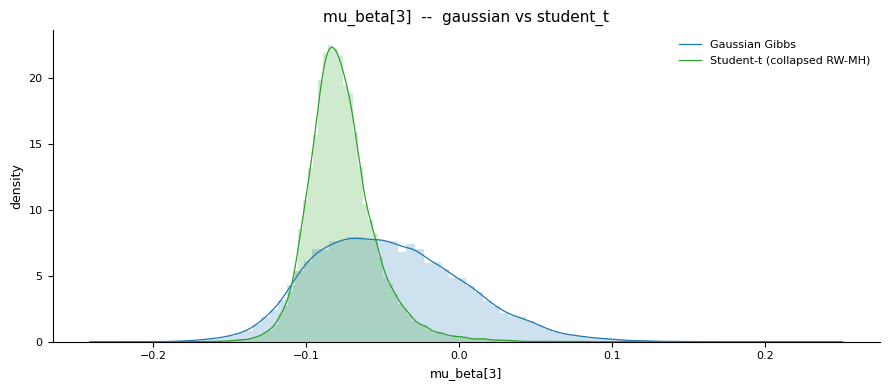

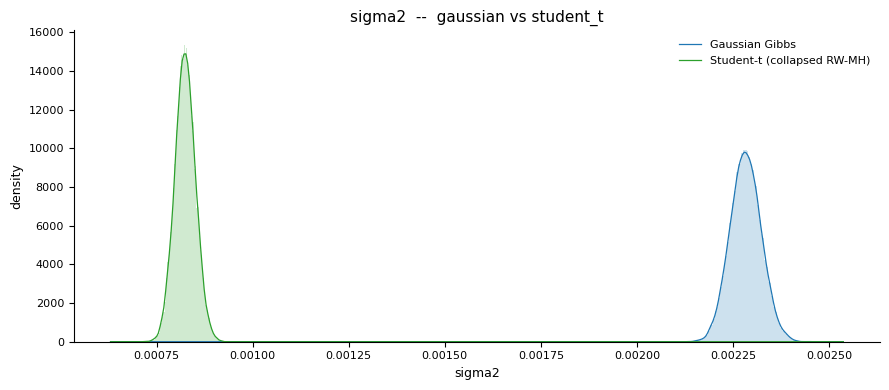

In [12]:
for j in range(p):
    samplers = {
        "gaussian":  trace_gauss["mu_beta"][..., j].reshape(-1),
        "student_t": trace_t["mu_beta"][..., j].reshape(-1),
    }
    fig, _ = plots.plot_posterior_overlay(samplers, param_name=f"mu_beta[{j}]")
    display(fig)

samplers_s2 = {
    "gaussian":  trace_gauss["sigma2"].reshape(-1),
    "student_t": trace_t["sigma2"].reshape(-1),
}
fig, _ = plots.plot_posterior_overlay(samplers_s2, param_name="sigma2")
display(fig)

## Closing observations

* The Gaussian sampler's R-hat is well below 1.05 across every scalar in
  `(mu_beta, sigma2, beta)` at production budget; ESS easily clears
  several hundred per parameter under the conjugate blocks.
* The Student-t sampler's `nu` block mixes substantially worse than the
  conjugate blocks (RW-MH on a single scalar with Robbins-Monro-tuned
  step), but stays inside the `[0.20, 0.45]` acceptance band per chain
  and clears the `ESS(nu) >= 400` gate at the production budget.
* The partial-collapse note on `propose_log_nu` is load-bearing: a
  reader expecting a `p(nu | lambda)` Gibbs step will be confused by
  the absence of one. The integrated-likelihood path (Liu-Wong-Kong)
  is what makes the chain tractable in the first place.
* The Gaussian-vs-Student-t overlay on `sigma2` is the single most
  informative comparison plot in this notebook -- it shows directly
  whether the heavy-tail specification is absorbing variance the
  Gaussian model would otherwise hide in `sigma^2`.
* nb 04 will take `trace_gauss` and `trace_t` as inputs to the
  Thompson policy and the per-state posterior on `Q(s, a)`; the cache
  files `data/processed/traces/gaussian_*.pkl` and
  `data/processed/traces/student_t_*.pkl` are the handoff.

In [13]:
# Provenance
assert trace_gauss["meta"]["sampler"] == "gaussian"
assert trace_t["meta"]["sampler"] == "student_t"
assert trace_gauss["beta"].shape == (4, 6000, n_actions, p)
assert trace_t["beta"].shape == (4, 6000, n_actions, p)
assert trace_t["nu_acceptance"].shape == (4,)

# Production-budget contracts (mirrors tests/test_sampler*_recovery.py)
assert max(rhat_gauss.values()) < 1.05, (
    f"Gaussian R-hat max = {max(rhat_gauss.values())} >= 1.05"
)
assert max(rhat_t.values()) < 1.05, (
    f"Student-t R-hat max = {max(rhat_t.values())} >= 1.05"
)
assert ess_t["nu"] >= 400, f"ESS(nu) = {ess_t['nu']:.0f} < 400"
assert (0.20 <= trace_t["nu_acceptance"]).all() and (trace_t["nu_acceptance"] <= 0.45).all(), (
    f"nu MH acceptance per chain {trace_t['nu_acceptance']} outside [0.20, 0.45]"
)

# Cache provenance
assert gauss_key.exists() and t_key.exists()

print("OK")

OK
